# Tech Challenge FIAP — Fase 1
## Notebook 01 — Análise Exploratória de Dados (EDA)

**Dataset:** Maternal Health Risk Data Set (UCI)
**Autor:** Igor Natanael

---

### Objetivo deste notebook
1. Carregar a base e descrever sua estrutura.
2. Calcular estatísticas descritivas e visualizar distribuições.
3. Investigar balanceamento do alvo, valores ausentes e duplicados.
4. Analisar correlações entre variáveis.
5. Identificar padrões e anomalias relevantes para o problema clínico.
6. Registrar conclusões que orientarão o pré-processamento e a modelagem.

## 1. Setup e imports

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.pipelines.data_loading import load_dataset, TARGET_COLUMN

sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 100
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)

RANDOM_STATE = 42

## 2. Carregamento dos dados

In [2]:
df = load_dataset()
print(f'Shape: {df.shape}')
df.head()

Shape: (1014, 7)


,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,RiskLevel
0,25,130,80,15.0,98.0,86,high risk
1,35,140,90,13.0,98.0,70,high risk
2,29,90,70,8.0,100.0,80,high risk
3,30,140,85,7.0,98.0,70,high risk
4,35,120,60,6.1,98.0,76,low risk


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1014 entries, 0 to 1013
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Age          1014 non-null   int64  
 1   SystolicBP   1014 non-null   int64  
 2   DiastolicBP  1014 non-null   int64  
 3   BS           1014 non-null   float64
 4   BodyTemp     1014 non-null   float64
 5   HeartRate    1014 non-null   int64  
 6   RiskLevel    1014 non-null   str    
dtypes: float64(2), int64(4), str(1)
memory usage: 55.6 KB


### Dicionário de variáveis

| Coluna | Descrição | Unidade |
|---|---|---|
| `Age` | Idade da paciente | anos |
| `SystolicBP` | Pressão arterial sistólica | mmHg |
| `DiastolicBP` | Pressão arterial diastólica | mmHg |
| `BS` | Glicemia (Blood Sugar) | mmol/L |
| `BodyTemp` | Temperatura corporal | °F |
| `HeartRate` | Frequência cardíaca | bpm |
| `RiskLevel` | **Alvo** — nível de risco gestacional | low / mid / high |

## 3. Estatísticas descritivas

In [4]:
df.describe().round(2)

,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate
count,1014.00,1014.0,1014.00,1014.00,1014.00,1014.00
mean,29.87,113.2,76.46,8.73,98.67,74.30
std,13.47,18.4,13.89,3.29,1.37,8.09
min,10.00,70.0,49.00,6.00,98.00,7.00
25%,19.00,100.0,65.00,6.90,98.00,70.00
50%,26.00,120.0,80.00,7.50,98.00,76.00
75%,39.00,120.0,90.00,8.00,98.00,80.00
max,70.00,160.0,100.00,19.00,103.00,90.00


In [5]:
# Medianas por classe (visao mais robusta que media frente a outliers)
df.groupby(TARGET_COLUMN).median(numeric_only=True).round(2)

,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate
RiskLevel,,,,,,
high risk,35.0,130.0,90.0,11.0,98.0,77.0
low risk,22.0,120.0,75.0,7.5,98.0,70.0
mid risk,25.0,120.0,75.0,7.0,98.0,76.0


## 4. Qualidade dos dados

### 4.1 Valores ausentes

In [6]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
pd.DataFrame({'ausentes': missing, 'percentual': missing_pct})

,ausentes,percentual
Age,0,0.0
SystolicBP,0,0.0
DiastolicBP,0,0.0
BS,0,0.0
BodyTemp,0,0.0
HeartRate,0,0.0
RiskLevel,0,0.0


### 4.2 Duplicatas

In [7]:
n_dup = df.duplicated().sum()
print(f'Linhas duplicadas: {n_dup} ({n_dup / len(df) * 100:.2f}%)')
print(f'Linhas unicas: {len(df) - n_dup}')
if n_dup > 0:
    df[df.duplicated(keep=False)].sort_values(by=df.columns.tolist()).head(10)

Linhas duplicadas: 562 (55.42%)
Linhas unicas: 452


### 4.3 Valores fora de faixas plausíveis

Sanity check clínico — valores que destoam da fisiologia humana indicam ruído de sensor ou erro de digitação.

In [8]:
plausible_ranges = {
    'Age': (10, 70),
    'SystolicBP': (70, 200),
    'DiastolicBP': (40, 130),
    'BS': (3, 20),
    'BodyTemp': (95, 105),
    'HeartRate': (40, 180),
}

for col, (low, high) in plausible_ranges.items():
    out = df[(df[col] < low) | (df[col] > high)]
    if len(out) > 0:
        print(f'{col}: {len(out)} valores fora de [{low}, {high}]')
        print(out[col].value_counts())
        print('---')

HeartRate: 2 valores fora de [40, 180]
HeartRate
7    2
Name: count, dtype: int64
---


## 5. Distribuição do alvo (balanceamento de classes)

           contagem  percentual
RiskLevel                      
low risk        406       40.04
mid risk        336       33.14
high risk       272       26.82


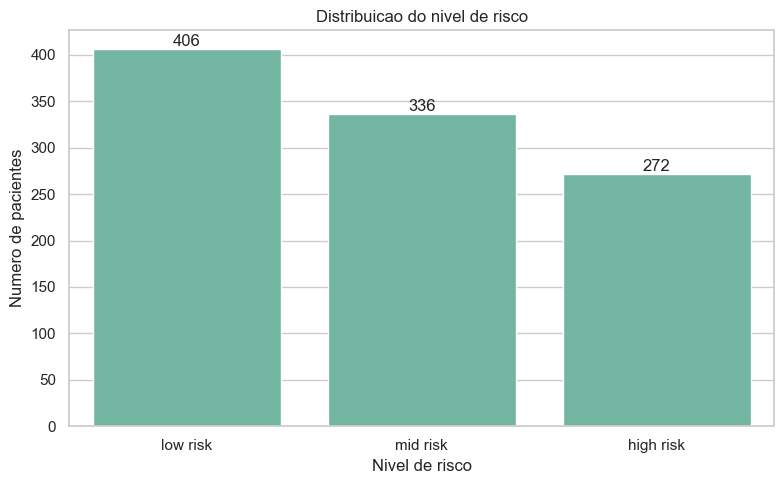

In [9]:
order = ['low risk', 'mid risk', 'high risk']
target_counts = df[TARGET_COLUMN].value_counts().reindex(order)
target_pct = (target_counts / len(df) * 100).round(2)

print(pd.DataFrame({'contagem': target_counts, 'percentual': target_pct}))

fig, ax = plt.subplots(figsize=(8, 5))
sns.countplot(data=df, x=TARGET_COLUMN, order=order, ax=ax)
ax.set_title('Distribuicao do nivel de risco')
ax.set_xlabel('Nivel de risco')
ax.set_ylabel('Numero de pacientes')
for p in ax.patches:
    ax.annotate(int(p.get_height()), (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom')
plt.tight_layout()
plt.savefig('../reports/figures/01_target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Distribuição das features

### 6.1 Histogramas globais

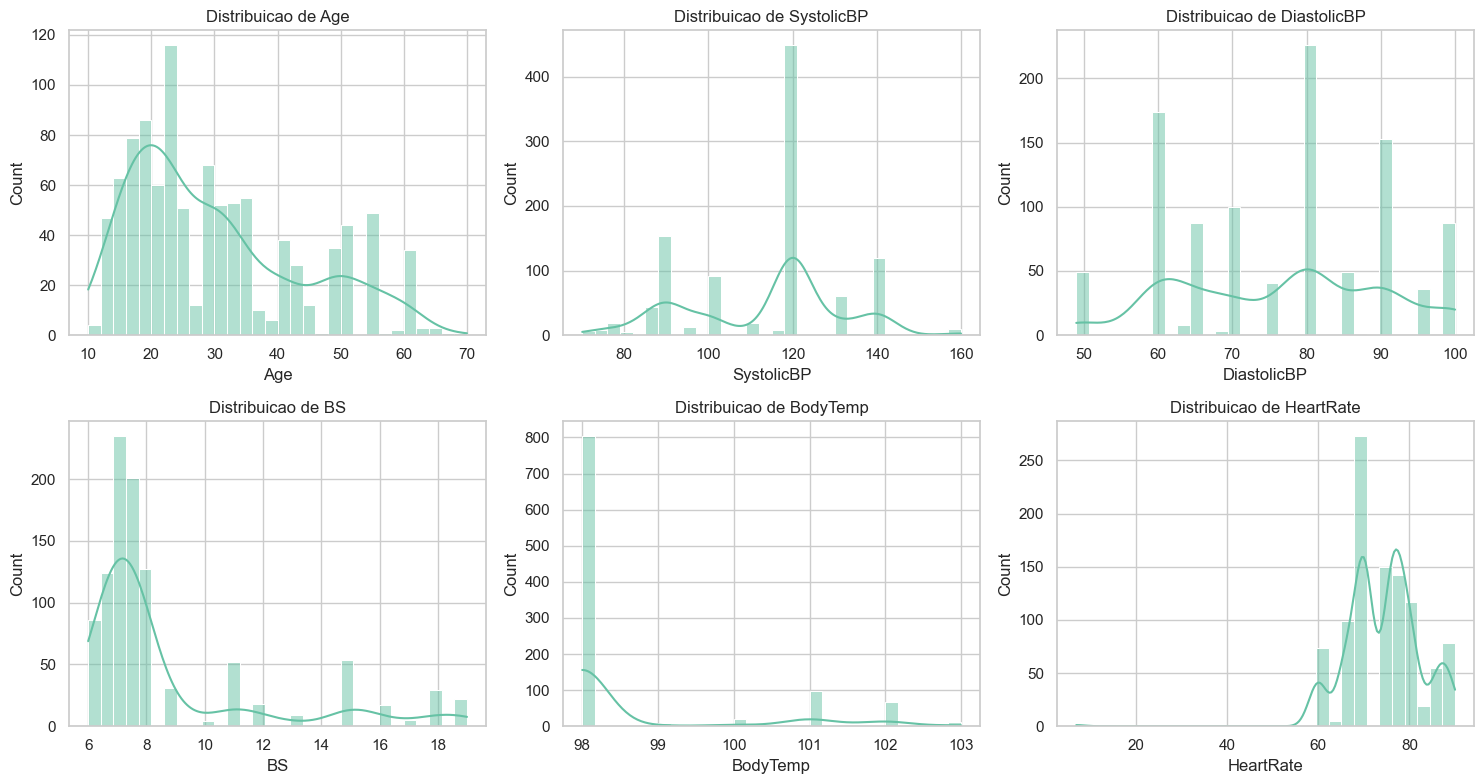

In [10]:
numeric_cols = [c for c in df.columns if c != TARGET_COLUMN]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flatten(), numeric_cols):
    sns.histplot(df[col], kde=True, ax=ax, bins=30)
    ax.set_title(f'Distribuicao de {col}')
plt.tight_layout()
plt.savefig('../reports/figures/02_feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

### 6.2 Boxplots por nível de risco

Mostra como cada variável se separa entre as três classes — indício forte de poder preditivo.

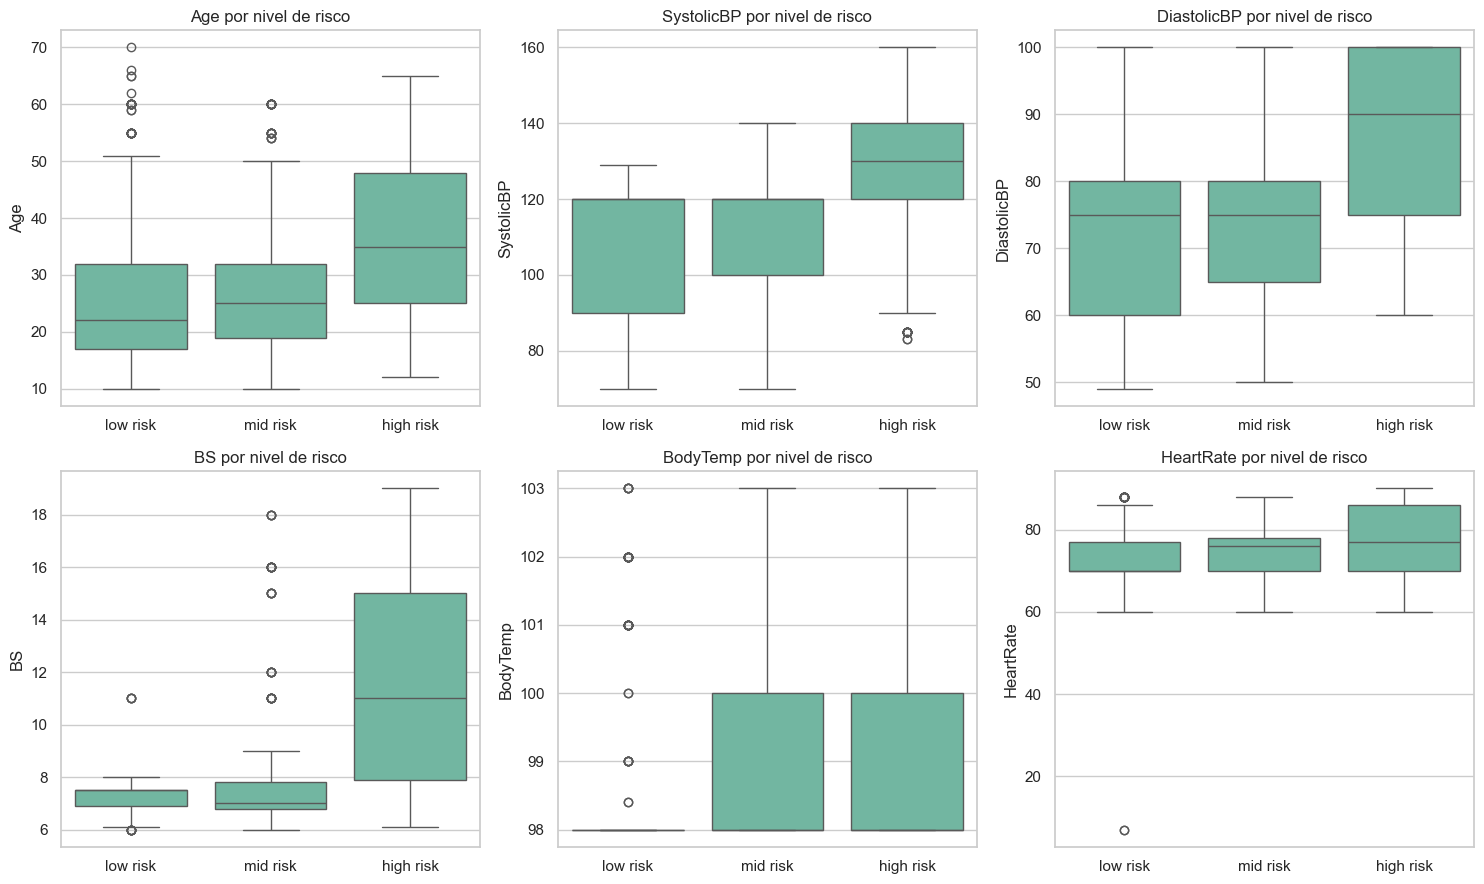

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for ax, col in zip(axes.flatten(), numeric_cols):
    sns.boxplot(data=df, x=TARGET_COLUMN, y=col, order=order, ax=ax)
    ax.set_title(f'{col} por nivel de risco')
    ax.set_xlabel('')
plt.tight_layout()
plt.savefig('../reports/figures/03_boxplots_by_risk.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Análise de correlação

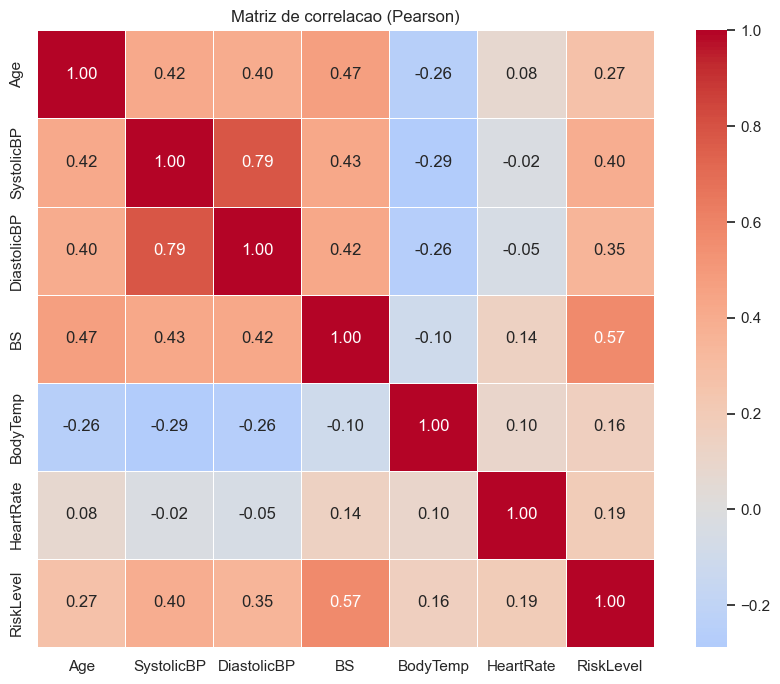

In [12]:
# Codificacao temporaria do alvo como ordinal (low=0, mid=1, high=2)
risk_map = {'low risk': 0, 'mid risk': 1, 'high risk': 2}
df_corr = df.copy()
df_corr[TARGET_COLUMN] = df_corr[TARGET_COLUMN].map(risk_map)

corr = df_corr.corr(method='pearson')

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, ax=ax)
ax.set_title('Matriz de correlacao (Pearson)')
plt.tight_layout()
plt.savefig('../reports/figures/04_correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

In [13]:
corr_target = corr[TARGET_COLUMN].drop(TARGET_COLUMN).sort_values(key=abs, ascending=False)
print('Correlacao com RiskLevel (Pearson, |r| ranqueado):')
print(corr_target.round(3))

Correlacao com RiskLevel (Pearson, |r| ranqueado):
BS             0.570
SystolicBP     0.396
DiastolicBP    0.347
Age            0.267
HeartRate      0.194
BodyTemp       0.164
Name: RiskLevel, dtype: float64


## 8. Pairplot por classe

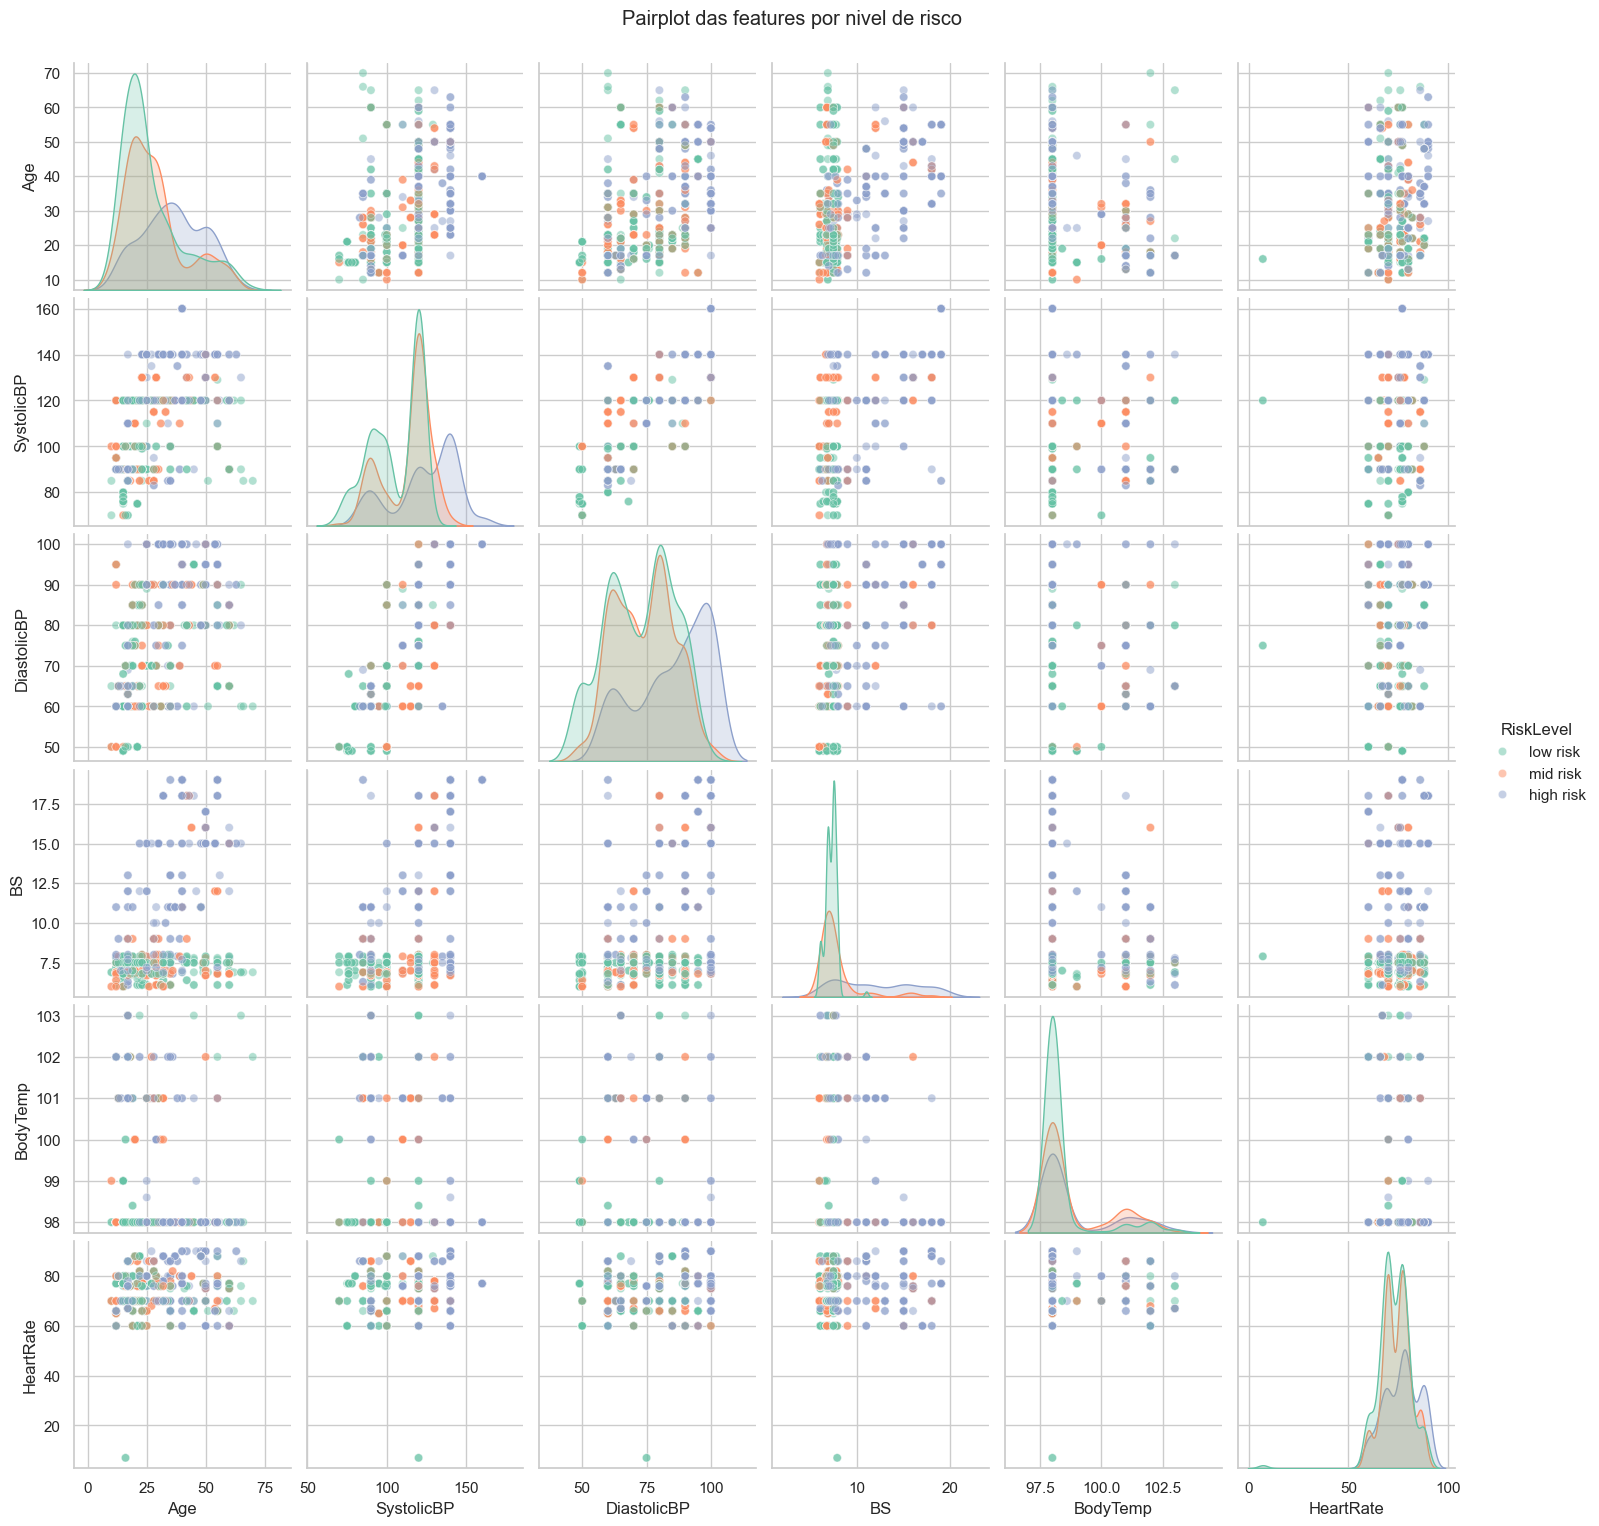

In [14]:
g = sns.pairplot(df, hue=TARGET_COLUMN, hue_order=order,
                 vars=numeric_cols, diag_kind='kde', plot_kws={'alpha': 0.5})
g.fig.suptitle('Pairplot das features por nivel de risco', y=1.02)
plt.savefig('../reports/figures/05_pairplot.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Discussão e conclusões da EDA

### 9.1 Tamanho e qualidade da base

- **1.014 registros × 7 colunas**, todas as features numéricas e o alvo categórico (3 classes). **Sem valores ausentes.**
- **Outliers fisiologicamente inválidos:** 2 registros com `HeartRate = 7 bpm` — impossível em humano vivo, provável erro de digitação (omissão do dígito 0 em 70). Decisão: **remover** ou **imputar** com a mediana da classe correspondente. Vamos remover, pois são apenas 2 linhas em ~1.000.
- **Duplicatas: 562 (55,42%)** — achado relevante. O dataset apresenta linhas idênticas, comum em medições com variáveis discretas e categorias clínicas (idade inteira, BP em incrementos de 5/10 mmHg). Decisão: **remover duplicatas antes do split treino/teste** para evitar *data leakage* — sem isso, a mesma observação pode aparecer em treino e teste, inflando artificialmente a acurácia. Trabalharemos com ~452 registros únicos.

### 9.2 Balanceamento do alvo

| Classe | Contagem | % |
|---|---|---|
| low risk | 406 | 40,0% |
| mid risk | 336 | 33,1% |
| high risk | 272 | 26,8% |

Desbalanceamento **moderado**. Não justifica SMOTE agressivo, mas vale usar `class_weight='balanced'` nos modelos compatíveis. Métrica principal: **F1-score macro** + **recall por classe** (foco no recall de `high risk`).

### 9.3 Variáveis mais separadoras

Observando os boxplots e medianas por classe:

| Variável | low risk | mid risk | high risk | Comentário |
|---|---|---|---|---|
| Age | 22 | 25 | 35 | Risco alto em pacientes mais velhas |
| SystolicBP | 120 | 120 | 130 | Hipertensão associada a risco alto |
| DiastolicBP | 75 | 75 | 90 | Mesma direção da sistólica |
| BS (glicose) | 7,5 | 7,0 | 11,0 | **Maior poder de separação** |
| BodyTemp | 98 | 98 | 98 | Pouco discriminativa em mediana |
| HeartRate | 70 | 76 | 77 | Diferença pequena |

Observação: **`mid risk` é frequentemente indistinguível de `low risk` nas medianas** (BP, BS) — provavelmente será a classe mais difícil de classificar.

### 9.4 Correlações com o alvo

Codificando o alvo como ordinal (low=0, mid=1, high=2):

| Feature | Pearson r |
|---|---|
| BS | 0,570 |
| SystolicBP | 0,396 |
| DiastolicBP | 0,347 |
| Age | 0,267 |
| HeartRate | 0,194 |
| BodyTemp | 0,164 |

Glicemia (`BS`) é, isoladamente, a feature mais informativa. Nenhuma feature tem correlação muito alta — sinal de que o problema exige modelos capazes de capturar **interações** entre variáveis (ex.: árvore/floresta).

### 9.5 Multicolinearidade

- **`SystolicBP` ↔ `DiastolicBP`: r = 0,787** (alta) — esperado clinicamente.
- Demais pares com |r| < 0,5.

Implicações:
- **Modelos lineares (Regressão Logística):** vão sofrer com a colinearidade — usar regularização (L2) ou criar feature derivada (ex.: *pulse pressure* = SystolicBP − DiastolicBP).
- **Modelos de árvore (Random Forest, XGBoost):** lidam naturalmente, sem necessidade de tratamento.

### 9.6 Padrões clínicos coerentes

Os padrões observados (idade mais alta, hipertensão e hiperglicemia associadas a risco alto) são **clinicamente plausíveis** — pré-eclâmpsia, diabetes gestacional e idade avançada são fatores de risco gestacional bem documentados. Isso aumenta a confiança no dataset e indica que features importantes capturam sinal real, não ruído.

### 9.7 Decisões para o pré-processamento

1. Remover 2 linhas com `HeartRate = 7` (outliers impossíveis).
2. Remover linhas duplicadas (de ~1.014 → ~452 únicas).
3. Codificar o alvo: `low=0, mid=1, high=2` (ordinal — preserva a ordem do risco).
4. Padronização (`StandardScaler`) das features numéricas — necessária para Regressão Logística e KNN; opcional para árvores.
5. Avaliar criação da feature derivada `pulse_pressure = SystolicBP − DiastolicBP` para a Regressão Logística.
6. Split estratificado 80/20 (preservando a proporção das classes), com `random_state=42`.

### 9.8 Métrica prioritária

**F1-score macro** como métrica principal, e **recall da classe `high risk`** como métrica de segurança clínica.

Justificativa: o custo de **falso negativo** numa paciente de alto risco (não detectada como tal) é incomparavelmente maior que o de um falso positivo (paciente de baixo risco encaminhada para avaliação adicional). O sistema deve **errar para o lado da segurança** — preferimos sobrediagnosticar a subdiagnosticar. Acurácia simples seria enganosa diante do desbalanceamento.

### 9.9 Próximos passos

1. Implementar pipeline de pré-processamento (`src/pipelines/preprocessing.py`).
2. Treinar 3 modelos para comparação: **Regressão Logística** (baseline), **Random Forest**, **XGBoost** ou **LightGBM**.
3. Validação cruzada estratificada (k=5).
4. Tuning de hiperparâmetros do melhor modelo (GridSearch).
5. SHAP para explicabilidade individual e global.